In [52]:
import os
size = os.path.getsize("/content/WELFake_Dataset.csv")
print(f"File size: {size / 1024 / 1024:.1f} MB")

File size: 233.7 MB


In [53]:
!pip install shap lime -q

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc)
from sklearn.pipeline import Pipeline
import joblib

import re
import os
import warnings
warnings.filterwarnings('ignore')
os.makedirs("outputs", exist_ok=True)

In [55]:
print("Load dataset......")
df=pd.read_csv("/content/WELFake_Dataset.csv")
print(f"Done load with {df.shape[0]:,} rows and with {df.shape[1]:,} columns ")


Load dataset......
Done load with 72,134 rows and with 4 columns 


In [56]:
print(df.columns.tolist())
print()
print(df.head(5).to_string())

['Unnamed: 0', 'title', 'text', 'label']

   Unnamed: 0                                                                                                                                      title                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

In [57]:
# Show column names clearly
print("Columns:", df.columns.tolist())
print()

# Show shape
print(f"Rows: {df.shape[0]:,}")
print(f"Cols: {df.shape[1]}")
print()

# Show first 3 rows — only title and label (easier to read)
print(df[["title", "label"]].head(3).to_string())

missing=df.isnull().sum()
missing_pct=(missing/len(df)*100).round(2)

missing_table=pd.DataFrame({
    "missing":missing,
    "missing_pct":missing_pct

})

print(missing_table)
print()
print(f"total missing values: {missing.sum()}")



Columns: ['Unnamed: 0', 'title', 'text', 'label']

Rows: 72,134
Cols: 4

                                                                                                                                       title  label
0         LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terrorists [VIDEO]      1
1                                                                                                                                        NaN      1
2  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MOST CHARLOTTE RIOTERS WERE “PEACEFUL” PROTESTERS…In Her Home State Of North Carolina [VIDEO]      1
            missing  missing_pct
Unnamed: 0        0         0.00
title           558         0.77
text             39         0.05
label             0         0.00

total missing values: 597


In [58]:
# df=df.drop(columns=["Unnamed: 0"])
# print("dropped the unnamed column")

df["title"]=df["title"].fillna("")
df["text"]=df["text"].fillna("")
print("Filled missin values with empty string")

df["Combied"]=df["title"]+""+df["text"]
print("Combined the title and text")

print()
print("Missing values afetr fix")
print(df.isnull().sum())
print()

print(df.head(10))

Filled missin values with empty string
Combined the title and text

Missing values afetr fix
Unnamed: 0    0
title         0
text          0
label         0
Combied       0
dtype: int64

   Unnamed: 0                                              title  \
0           0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...   
1           1                                                      
2           2  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...   
3           3  Bobby Jindal, raised Hindu, uses story of Chri...   
4           4  SATAN 2: Russia unvelis an image of its terrif...   
5           5  About Time! Christian Group Sues Amazon and SP...   
6           6  DR BEN CARSON TARGETED BY THE IRS: “I never ha...   
7           7  HOUSE INTEL CHAIR On Trump-Russia Fake Story: ...   
8           8  Sports Bar Owner Bans NFL Games…Will Show Only...   
9           9  Latest Pipeline Leak Underscores Dangers Of Da...   

                                                text  label  \
0

In [59]:
df=df.rename(columns={"Combied":"combined"})

x=df.columns.tolist()
print(x)

# print(df.head(10))

['Unnamed: 0', 'title', 'text', 'label', 'combined']


In [60]:
import re

def clean_text(text):
  text=str(text)
  text=text.lower()
  text=re.sub(r"http\S+|www\s+", "", text)
  text=re.sub(r"[^a-z\s]","", text)
  text=re.sub(r"\s+", " ", text)
  text=text.strip()
  return text
raw='SHOCKING!!! Government HIDES cancer cure http://fakenews.com!!!'
cleaned= clean_text(raw)

print("before clean :" , raw)
print("after clean :" , cleaned)


before clean : SHOCKING!!! Government HIDES cancer cure http://fakenews.com!!!
after clean : shocking government hides cancer cure


In [61]:
df["clean_text"]=df["combined"].apply(clean_text)

for i in[0, 1, 3]:
  print("Before:", df["combined"].iloc[i][:100])
  print("After:", df["clean_text"].iloc[i][:100])
  print()

Before: LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter 
After: law enforcement on high alert following threats against cops and whites on by blacklivesmatter and f

Before: Did they post their votes for Hillary already?
After: did they post their votes for hillary already

Before: Bobby Jindal, raised Hindu, uses story of Christian conversion to woo evangelicals for potential 201
After: bobby jindal raised hindu uses story of christian conversion to woo evangelicals for potential bida 



In [62]:
# df=df.drop(columns=["Unnamed:0"])
print(f"Total_rows : {len(df):,}")
print(f"number Of columns : {df.columns.tolist()}")
print(f"Missing values : {df['clean_text'].isnull().sum()}")

print("to varify sample is going to be")
print(df['clean_text'].iloc[0][:100])


Total_rows : 72,134
number Of columns : ['Unnamed: 0', 'title', 'text', 'label', 'combined', 'clean_text']
Missing values : 0
to varify sample is going to be
law enforcement on high alert following threats against cops and whites on by blacklivesmatter and f


In [63]:
print("Clean text sample")
print(f"{df['clean_text'].iloc[3]}")

Clean text sample
bobby jindal raised hindu uses story of christian conversion to woo evangelicals for potential bida dozen politically active pastors came here for a private dinner friday night to hear a conversion story unique in the context of presidential politics how louisiana gov bobby jindal traveled from hinduism to protestant christianity and ultimately became what he calls an evangelical catholic over two hours jindal recalled talking with a girl in high school who wanted to save my soul reading the bible in a closet so his parents would not see him and feeling a stir while watching a movie during his senior year that depicted jesus on the cross i was struck and struck hard jindal told the pastors this was the son of god and he had died for our sins jindals session with the christian clergy who lead congregations in the early presidential battleground states of iowa and south carolina was part of a behindthescenes effort by the louisiana governor to find a political base that

In [64]:
vectorizer=TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    stop_words="english"
)


In [65]:
# spliting the data

X_train, X_test, y_train, y_test=train_test_split(
    df["clean_text"],
    df["label"],
    test_size=0.25,
    random_state=42,
    stratify=df["label"]
    )

print(f"Trainig set : {len(X_train):,} article")
print(f"Testing set: {len(X_test):,} article")
print(y_train.value_counts())
print(y_test.value_counts())




Trainig set : 54,100 article
Testing set: 18,034 article
label
1    27829
0    26271
Name: count, dtype: int64
label
1    9277
0    8757
Name: count, dtype: int64


In [66]:
print("Convert the text into number")

X_train_tfidf=vectorizer.fit_transform(X_train)
X_test_tfidf=vectorizer.transform(X_test)
print(f"\nX_train_tfidf shape: {X_train_tfidf.shape}")
print(f"\nX_test_tfidf shape: {X_test_tfidf.shape}")


Convert the text into number

X_train_tfidf shape: (54100, 5000)

X_test_tfidf shape: (18034, 5000)


In [67]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier


print("Training Model 1: Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)
print("Done!")


print("\nTraining Model 2: Naive Bayes...")
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)



print("\nTraining Model 3: Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_tfidf, y_train)


print("\n All 3 models trained successfully!")

Training Model 1: Logistic Regression...
Done!

Training Model 2: Naive Bayes...

Training Model 3: Random Forest...

 All 3 models trained successfully!


In [68]:
from sklearn.metrics import classification_report

models = {
    "Logistic Regression" : lr_model,
    "Naive Bayes"         : nb_model,
    "Random Forest"       : rf_model
}

print("=" * 55)
print("  MODEL EVALUATION ON TEST SET")
print("=" * 55)

for name, model in models.items():
    # Make predictions on test set
    y_pred = model.predict(X_test_tfidf)

    # Print results
    print(f"\n── {name} ──────────────────────────")
    print(classification_report(
        y_test, y_pred,
        target_names=["Real", "Fake"]
    ))

  MODEL EVALUATION ON TEST SET

── Logistic Regression ──────────────────────────
              precision    recall  f1-score   support

        Real       0.95      0.94      0.95      8757
        Fake       0.94      0.95      0.95      9277

    accuracy                           0.95     18034
   macro avg       0.95      0.95      0.95     18034
weighted avg       0.95      0.95      0.95     18034


── Naive Bayes ──────────────────────────
              precision    recall  f1-score   support

        Real       0.86      0.83      0.84      8757
        Fake       0.84      0.87      0.86      9277

    accuracy                           0.85     18034
   macro avg       0.85      0.85      0.85     18034
weighted avg       0.85      0.85      0.85     18034


── Random Forest ──────────────────────────
              precision    recall  f1-score   support

        Real       0.97      0.94      0.95      8757
        Fake       0.95      0.97      0.96      9277

    accuracy

In [69]:
import shap
import numpy as np

print("Converting to dense array...")
X_test_sample  = X_test_tfidf[:100].toarray()
X_train_sample = X_train_tfidf[:100].toarray()
print(f" Converted! Shape: {X_test_sample.shape}")

print("\nComputing SHAP values...")
print("(This may take 1-2 minutes)")

explainer = shap.TreeExplainer(
    rf_model,
    X_train_sample,
    feature_perturbation="interventional"
)

shap_values = explainer.shap_values(X_test_sample)

print(" SHAP values computed!")
print(f"Type: {type(shap_values)}")
print(f"Length: {len(shap_values)}")

Converting to dense array...
 Converted! Shape: (100, 5000)

Computing SHAP values...
(This may take 1-2 minutes)


 96%|=================== | 192/200 [00:24<00:01]       

 SHAP values computed!
Type: <class 'numpy.ndarray'>
Length: 100


Generating SHAP Global Bar Chart...


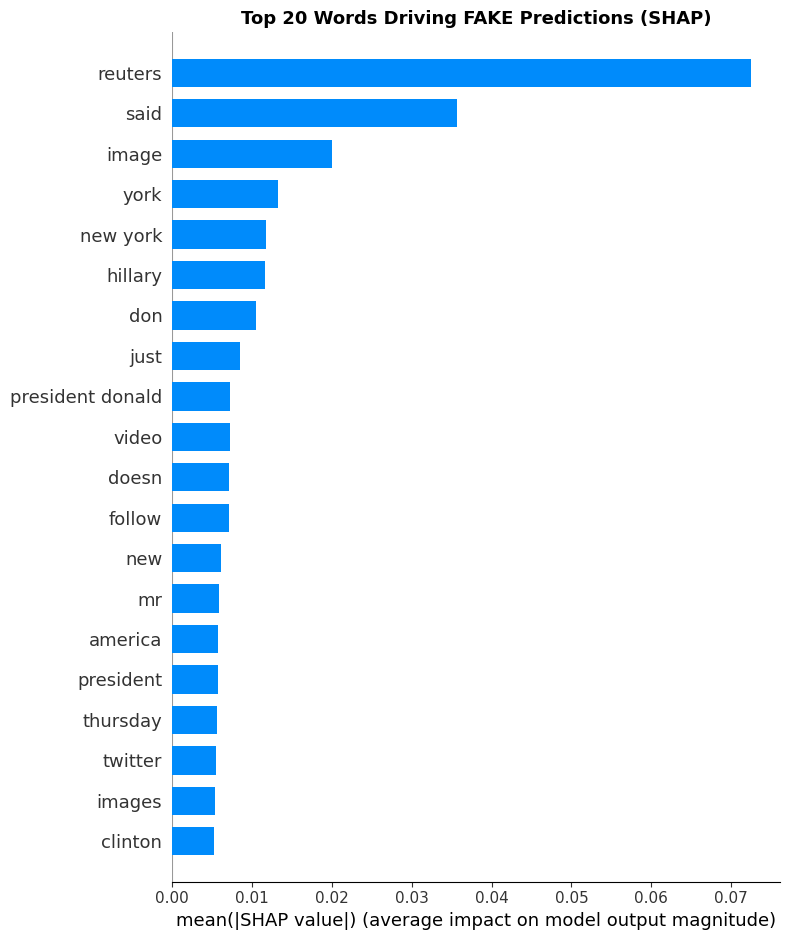

 Saved: shap_global_bar.png

Generating SHAP Beeswarm Plot...


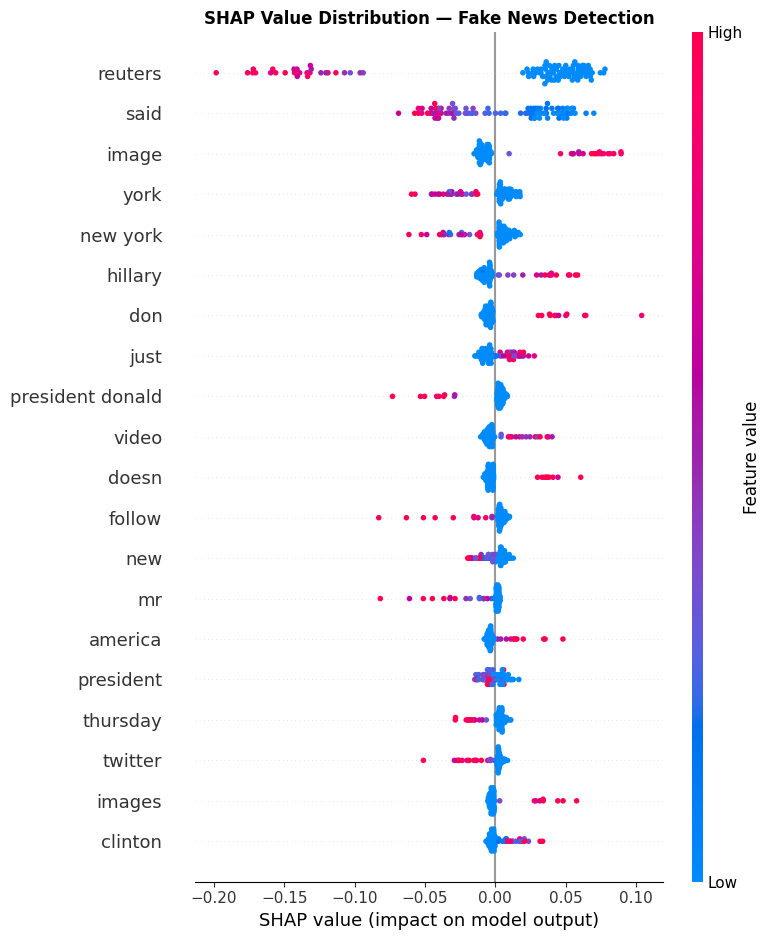

Saved: shap_beeswarm.png


In [70]:
import matplotlib.pyplot as plt


feature_names = vectorizer.get_feature_names_out()


print("Generating SHAP Global Bar Chart...")

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values[:, :, 1],
    X_test_sample,
    feature_names = feature_names,
    plot_type     = "bar",
    max_display   = 20,
    show          = False
)
plt.title("Top 20 Words Driving FAKE Predictions (SHAP)",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("shap_global_bar.png", dpi=150)
plt.show()
print(" Saved: shap_global_bar.png")


print("\nGenerating SHAP Beeswarm Plot...")

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values[:, :, 1],
    X_test_sample,
    feature_names = feature_names,
    max_display   = 20,
    show          = False
)
plt.title("SHAP Value Distribution — Fake News Detection",
          fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=150)
plt.show()
print("Saved: shap_beeswarm.png")

Article being explained:
"is smithsonian museum planning to make hero out of third rate qb race agitator colin kaepernickmartin luther king jr would not likely be pleased to se..."

Prediction : FAKE 🔴
Confidence : 97.0%


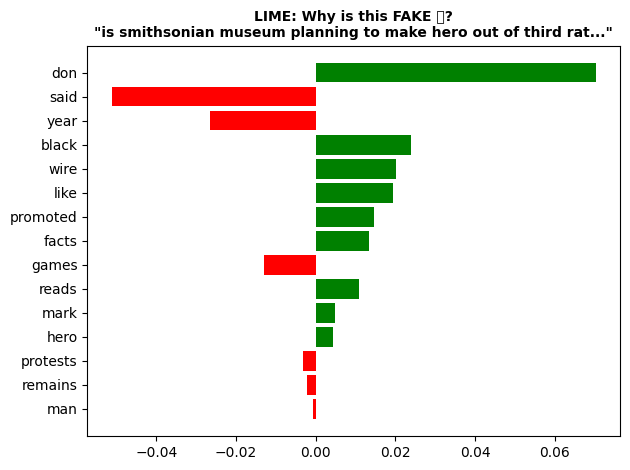

Saved: lime_explanation.png


In [71]:
import lime
import lime.lime_text
import numpy as np

def predict_proba(texts):
    tfidf   = vectorizer.transform(texts)
    return rf_model.predict_proba(tfidf)


lime_explainer = lime.lime_text.LimeTextExplainer(
    class_names=["Real", "Fake"]
)

fake_indices = [i for i, label in enumerate(y_test) if label == 1]
sample_text  = X_test.iloc[fake_indices[0]]

print(f"Article being explained:")
print(f'"{sample_text[:150]}..."')
print()

explanation = lime_explainer.explain_instance(
    sample_text,
    predict_proba,
    num_features = 15,
    num_samples  = 500
)


pred  = rf_model.predict(vectorizer.transform([sample_text]))[0]
proba = rf_model.predict_proba(vectorizer.transform([sample_text]))[0]
label = "FAKE 🔴" if pred == 1 else "REAL 🟢"

print(f"Prediction : {label}")
print(f"Confidence : {proba[pred]:.1%}")

fig = explanation.as_pyplot_figure()
plt.title(f'LIME: Why is this {label}?\n"{sample_text[:60]}..."',
          fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig("lime_explanation.png", dpi=150)
plt.show()
print("Saved: lime_explanation.png")